# Random Forest — Predicción de Tarifas NYC
## Proyecto 1 - Inteligencia Artificial 2026

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# Carga y preprocesamiento
Misma pipeline de limpieza que el notebook principal

In [8]:
SAMPLE_SIZE = 1_000_000

df = pd.read_csv(
    "../data/train.csv",
    nrows=SAMPLE_SIZE,
    parse_dates=["pickup_datetime"]
)
print(f"Cargadas {len(df):,} filas")

Cargadas 1,000,000 filas


In [9]:
# Limpieza
df_clean = df.copy()
df_clean = df_clean.dropna()
df_clean = df_clean[df_clean["fare_amount"] > 0]
df_clean = df_clean[df_clean["fare_amount"] <= 200]

LAT_MIN, LAT_MAX = 40.4774, 41.0755
LON_MIN, LON_MAX = -74.2591, -71.6966

df_clean = df_clean[
    df_clean["pickup_latitude"].between(LAT_MIN, LAT_MAX) &
    df_clean["pickup_longitude"].between(LON_MIN, LON_MAX) &
    df_clean["dropoff_latitude"].between(LAT_MIN, LAT_MAX) &
    df_clean["dropoff_longitude"].between(LON_MIN, LON_MAX)
]
df_clean = df_clean[df_clean["passenger_count"].between(1, 7)]
print(f"Despues de limpieza: {len(df_clean):,} filas")

Despues de limpieza: 974,993 filas


# Feature Engineering

In [10]:
# Distancia Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_clean["distance_km"] = haversine(
    df_clean["pickup_latitude"].values, df_clean["pickup_longitude"].values,
    df_clean["dropoff_latitude"].values, df_clean["dropoff_longitude"].values
)
df_clean = df_clean[df_clean["distance_km"] > 0]
df_clean = df_clean[df_clean["distance_km"] <= 100]

# Variables temporales
df_clean["hour"] = df_clean["pickup_datetime"].dt.hour
df_clean["day_of_week"] = df_clean["pickup_datetime"].dt.dayofweek
df_clean["month"] = df_clean["pickup_datetime"].dt.month
df_clean["year"] = df_clean["pickup_datetime"].dt.year

# Aeropuertos
AIRPORTS = {
    "jfk": {"lat": 40.6413, "lon": -73.7781, "radio": 0.05},
    "laguardia": {"lat": 40.7769, "lon": -73.8740, "radio": 0.03},
    "newark": {"lat": 40.6895, "lon": -74.1745, "radio": 0.04},
}

def cerca_aeropuerto(lat, lon, ap):
    a = AIRPORTS[ap]
    return ((np.abs(lat - a["lat"]) < a["radio"]) & (np.abs(lon - a["lon"]) < a["radio"])).astype(int)

for ap in AIRPORTS:
    df_clean[f"pickup_{ap}"] = cerca_aeropuerto(df_clean["pickup_latitude"], df_clean["pickup_longitude"], ap)
    df_clean[f"dropoff_{ap}"] = cerca_aeropuerto(df_clean["dropoff_latitude"], df_clean["dropoff_longitude"], ap)

print(f"Dataset final: {df_clean.shape}")

Dataset final: (964769, 19)


# Particion Train/Test

In [11]:
features = ["distance_km", "hour", "day_of_week", "month", "year",
            "passenger_count", "pickup_longitude", "pickup_latitude",
            "dropoff_longitude", "dropoff_latitude",
            "pickup_jfk", "pickup_laguardia", "pickup_newark",
            "dropoff_jfk", "dropoff_laguardia", "dropoff_newark"]

X = df_clean[features]
y = df_clean["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 771,815 filas
Test:  192,954 filas


In [12]:
def calcular_metricas(y_real, y_pred, nombre):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"\n--- {nombre} ---")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Modelo Random Forest

## Busqueda de hiperparametros

In [13]:
# Submuestra para grid search (con 770k filas tarda mucho)
SAMPLE_GS = 100_000
idx_sample = X_train.sample(n=SAMPLE_GS, random_state=42).index
X_sample = X_train.loc[idx_sample]
y_sample = y_train.loc[idx_sample]

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [15, 20, None],
    "min_samples_split": [5, 10]
}

print("Buscando mejores hiperparametros con GridSearchCV (3-fold)...")
print(f"Usando submuestra de {SAMPLE_GS:,} filas")
start = time.time()

gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1, n_jobs=-1
)
gs.fit(X_sample, y_sample)

tiempo_gs = time.time() - start
print(f"\nGrid Search terminado en {tiempo_gs:.1f} segundos")
print(f"Mejor combinacion: {gs.best_params_}")
print(f"Mejor MAE (CV): {-gs.best_score_:.4f}")

Buscando mejores hiperparametros con GridSearchCV (3-fold)...
Usando submuestra de 100,000 filas
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/home/DiegoPatzan/Documents/UVG/7MO/IA/Proyecto1_IA/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/DiegoPatzan/Documents/UVG/7MO/IA/Proyecto1_IA/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/DiegoPatzan/Documents/UVG/7MO/IA/Proyecto1_IA/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl


Grid Search terminado en 320.7 segundos
Mejor combinacion: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Mejor MAE (CV): 1.8245


In [14]:
# Resultados completos del grid search
resultados_gs = pd.DataFrame(gs.cv_results_)
cols = ["param_n_estimators", "param_max_depth", "param_min_samples_split",
        "mean_test_score", "std_test_score", "rank_test_score"]
resultados_gs = resultados_gs[cols].sort_values("rank_test_score")
resultados_gs["mean_test_score"] = -resultados_gs["mean_test_score"]
resultados_gs.columns = ["n_estimators", "max_depth", "min_samples_split", "MAE", "std", "rank"]
print("Todas las combinaciones probadas:")
display(resultados_gs)

Todas las combinaciones probadas:


,n_estimators,max_depth,min_samples_split,MAE,std,rank
11,200,None,10,1.824492,0.007614,1
7,200,20,10,1.826246,0.008121,2
9,200,None,5,1.828046,0.008010,3
5,200,20,5,1.828619,0.008856,4
10,100,None,10,1.829493,0.006273,5
6,100,20,10,1.830260,0.006600,6
4,100,20,5,1.833111,0.007269,7
8,100,None,5,1.833764,0.006876,8
3,200,15,10,1.843886,0.006867,9
1,200,15,5,1.844440,0.007548,10


## Entrenamiento con dataset completo

In [15]:
print("Entrenando Random Forest con todos los datos de train...")
start = time.time()

modelo_rf = RandomForestRegressor(
    **gs.best_params_,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

tiempo_rf = time.time() - start
print(f"Tiempo de entrenamiento: {tiempo_rf:.1f} segundos")
print(f"Hiperparametros: {gs.best_params_}")

Entrenando Random Forest con todos los datos de train...
Tiempo de entrenamiento: 216.9 segundos
Hiperparametros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [16]:
# Predicciones y metricas
y_pred_train_rf = modelo_rf.predict(X_train)
y_pred_test_rf = modelo_rf.predict(X_test)

print("===========================")
print("METRICAS - RANDOM FOREST")
print("===========================")

metricas_train_rf = calcular_metricas(y_train, y_pred_train_rf, "Train")
metricas_test_rf = calcular_metricas(y_test, y_pred_test_rf, "Test")

METRICAS - RANDOM FOREST

--- Train ---
  MAE:  0.9196
  RMSE: 1.9957
  R2:   0.9560

--- Test ---
  MAE:  1.6436
  RMSE: 3.4233
  R2:   0.8699


## Graficas de resultados

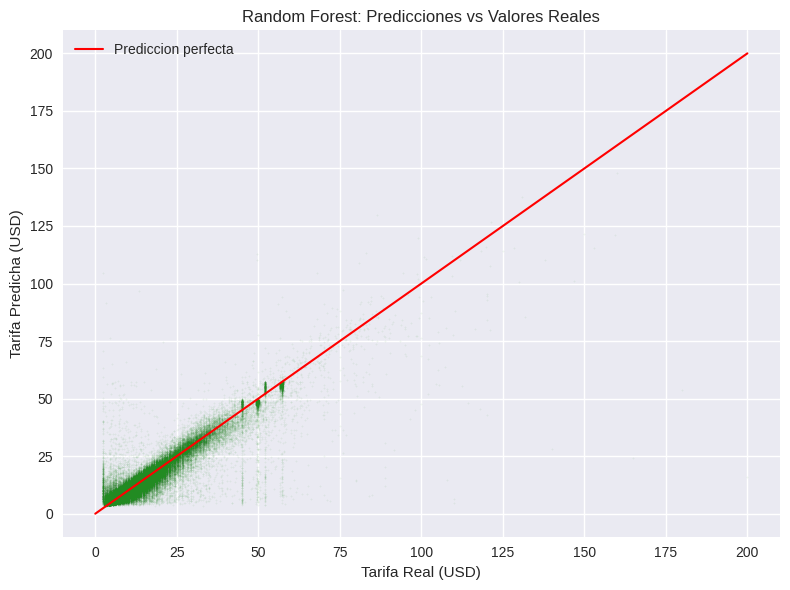

Grafica guardada


In [17]:
# Predicciones vs Valores Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_rf, alpha=0.05, s=1, color="forestgreen")
plt.plot([0, 200], [0, 200], color="red", linewidth=1.5, label="Prediccion perfecta")
plt.xlabel("Tarifa Real (USD)")
plt.ylabel("Tarifa Predicha (USD)")
plt.title("Random Forest: Predicciones vs Valores Reales")
plt.legend()
plt.tight_layout()
plt.savefig("rf_predicciones_vs_reales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada")

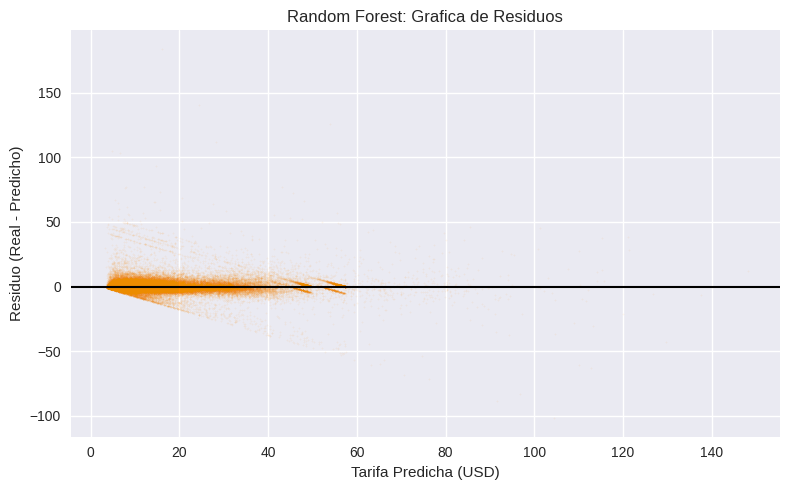

Grafica guardada


In [18]:
# Residuos
residuos_rf = y_test.values - y_pred_test_rf

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_rf, residuos_rf, alpha=0.05, s=1, color="darkorange")
plt.axhline(y=0, color="black", linewidth=1.5)
plt.xlabel("Tarifa Predicha (USD)")
plt.ylabel("Residuo (Real - Predicho)")
plt.title("Random Forest: Grafica de Residuos")
plt.tight_layout()
plt.savefig("rf_residuos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada")

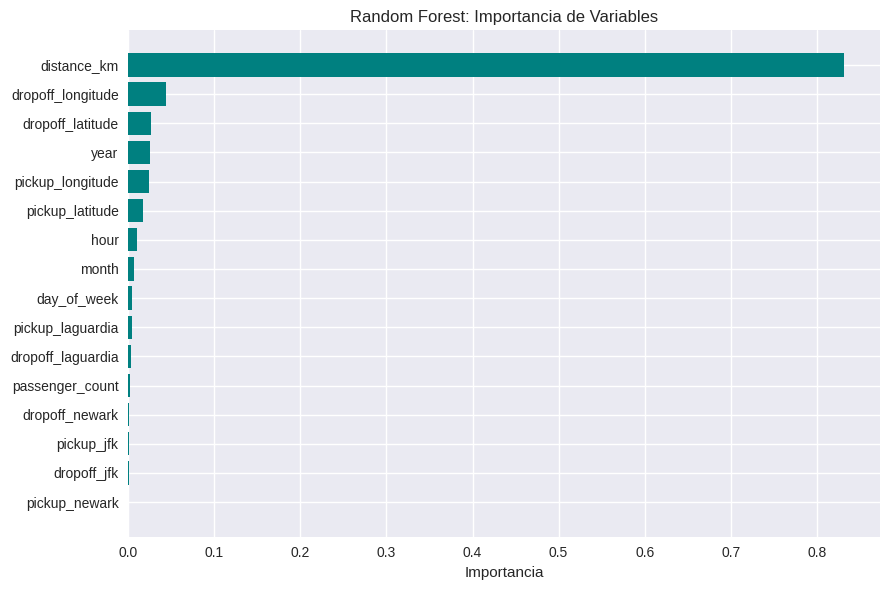

Grafica guardada


In [19]:
# Importancia de features
importancias = pd.DataFrame({
    "Feature": features,
    "Importancia": modelo_rf.feature_importances_
}).sort_values("Importancia", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importancias["Feature"], importancias["Importancia"], color="teal")
plt.xlabel("Importancia")
plt.title("Random Forest: Importancia de Variables")
plt.tight_layout()
plt.savefig("rf_importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada")

## Analisis de puntos de alta influencia

In [20]:
# Top 10 predicciones con mayor error
errores = np.abs(y_test.values - y_pred_test_rf)
idx_peores = np.argsort(errores)[-10:][::-1]

df_peores = X_test.iloc[idx_peores].copy()
df_peores["tarifa_real"] = y_test.values[idx_peores]
df_peores["prediccion"] = y_pred_test_rf[idx_peores]
df_peores["error_abs"] = errores[idx_peores]

print("Top 10 predicciones con mayor error:")
display(df_peores[["distance_km", "hour", "tarifa_real", "prediccion", "error_abs",
                    "pickup_jfk", "dropoff_jfk", "pickup_newark", "dropoff_newark"]])

Top 10 predicciones con mayor error:


,distance_km,hour,tarifa_real,prediccion,error_abs,pickup_jfk,dropoff_jfk,pickup_newark,dropoff_newark
888904,2.923828,15,200.0,15.979742,184.020258,0,0,0,0
1483,0.028489,21,165.0,24.336886,140.663114,0,0,0,0
704765,0.745541,11,180.0,53.935042,126.064958,0,0,0,0
821319,0.000810,1,140.0,28.240237,111.759763,0,0,0,0
409494,0.005872,14,110.0,4.745257,105.254743,0,0,0,0
25799,0.003638,3,110.0,6.593333,103.406667,0,0,0,0
269715,0.000905,5,2.5,104.406820,101.906820,0,0,0,0
14142,3.828609,10,108.0,14.613907,93.386093,0,0,0,0
399173,0.002892,10,3.3,91.530725,88.230725,0,0,0,0
150383,27.408678,5,13.5,96.689150,83.189150,0,0,0,0


In [21]:
# Comparativa train vs test (detectar overfitting)
comparacion = pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Train": [metricas_train_rf["MAE"], metricas_train_rf["RMSE"], metricas_train_rf["R2"]],
    "Test": [metricas_test_rf["MAE"], metricas_test_rf["RMSE"], metricas_test_rf["R2"]]
})
comparacion["Diferencia"] = comparacion["Train"] - comparacion["Test"]

print("Comparacion Train vs Test:")
display(comparacion)

diff_r2 = metricas_train_rf["R2"] - metricas_test_rf["R2"]
if diff_r2 > 0.05:
    print(f"\nAtencion: diferencia de R2 = {diff_r2:.4f}, posible overfitting")
else:
    print(f"\nDiferencia de R2 = {diff_r2:.4f}, no hay overfitting significativo")

Comparacion Train vs Test:


,Metrica,Train,Test,Diferencia
0,MAE,0.919575,1.643578,-0.724002
1,RMSE,1.995729,3.423347,-1.427618
2,R2,0.956030,0.869913,0.086117



Atencion: diferencia de R2 = 0.0861, posible overfitting
